# Session Monitoring: A Real Crawl Run's Round-by-Round Behavior

**Research question.** The other notebooks in this directory measure the pipeline under
controlled, repeatable conditions (a fixed sample, a fixed batch size). This notebook
instead looks at an actual, uncontrolled `python src/main.py` run started for real-world
testing (see the README's "Session monitoring" section): how did round size, fetch
success, and category/quality mix change over the course of that run, and how much did
search-discovery batches actually contribute? Because a real run can be stopped, crash, or
be interrupted at any point, the underlying data (`model.tools.monitor_service`'s
crash-safe session log, binned against the `crawls` table by
`experiments/analyze_session.py`) is designed to stay usable even from a partial run - see
that script's docstring for exactly how.

**Data.** Produced in two steps:

1. `python experiments/analyze_session.py [session_log.jsonl] [db_path]` - reads a
   `sessions/session_<timestamp>.jsonl` log (written continuously while `src/main.py`
   runs) plus the crawl database it refers to, and writes
   `experiments/data/session_<timestamp>_rounds.csv` /
   `..._discovery.csv`.
2. This notebook loads the most recently produced pair of those CSVs (override the
   `SESSION` variable below to analyze an older one instead) and plots them.

To analyze a session captured on a different machine: copy over its
`sessions/session_<timestamp>.jsonl` and the `crawl.db` it was writing to, run step 1
against those two paths, then re-run this notebook (`jupyter nbconvert --to notebook
--execute --inplace notebooks/session_monitoring.ipynb` for a headless re-run, or
interactively for a specific `SESSION`).

In [1]:
import sys
sys.path.insert(0, ".")
from plotting import set_style, savefig, load_csv, PALETTE, integer_axis, find_latest_session_prefix
import matplotlib.pyplot as plt
import pandas as pd

set_style()

# Which session to analyze - defaults to the most recently produced
# experiments/data/session_*_rounds.csv (see experiments/analyze_session.py).
# Override to analyze a specific/older session instead, e.g.:
#   SESSION = "session_20260822_022754"
SESSION = find_latest_session_prefix()
print(f"Analyzing session: {SESSION}")

rounds = load_csv(f"{SESSION}_rounds.csv")
discovery = load_csv(f"{SESSION}_discovery.csv")
rounds

Analyzing session: session_20260822_153136


,round,queued,round_seconds,fetched,fetch_success,fetch_failed,cat_(uncategorized),cat_IRRELEVANT,cat_LIST,cat_STATION
0,1,6,1419.703,6,6,0,0,0,4,2
1,2,428,13305.828,400,393,7,10,111,142,137
2,3,3994,NaN,3725,3502,223,232,1799,450,1244


## Which categories count as "quality" links

Rather than hardcoding category names, relevance is read live from the same `bot.config`
the crawl itself used (`relevancy[<category>]`) - consistent with this project's
config-driven-framework framing (see the thesis overview): a page in a category marked
`relevancy = True` (e.g. `STATION`/`LIST`) is a "useful" fetch, everything else
(`IRRELEVANT`, or `(uncategorized)` for pages fetched but not yet categorized when
monitoring stopped) is not.

In [2]:
import model.tools.config_service as config_service

# _read_config() reads the raw bot.config dict without building a full validated
# Config - the latter loads every configured LLM model as a side effect
# (model.tools.llm_service.get_model_id()), which this notebook has no need to pay for.
_raw_config = config_service._read_config()
_category_names = _raw_config["categories"].split("|")
CATEGORY_RELEVANCE = {name: _raw_config[f"relevancy[{name}]"] == "True" for name in _category_names}
CATEGORY_RELEVANCE

{'STATION': True, 'LIST': True, 'IRRELEVANT': False}

In [3]:
cat_columns = [c for c in rounds.columns if c.startswith("cat_")]


def _is_relevant_column(col):
    name = col[len("cat_"):]
    return CATEGORY_RELEVANCE.get(name, False)  # "(uncategorized)" -> not a real category -> False


relevant_columns = [c for c in cat_columns if _is_relevant_column(c)]
irrelevant_columns = [c for c in cat_columns if not _is_relevant_column(c)]

rounds["relevant_count"] = rounds[relevant_columns].sum(axis=1) if relevant_columns else 0
rounds["relevant_ratio"] = rounds["relevant_count"] / rounds["fetched"].replace(0, pd.NA)
rounds[["round", "queued", "fetched", "fetch_failed", "relevant_count", "relevant_ratio"]]

,round,queued,fetched,fetch_failed,relevant_count,relevant_ratio
0,1,6,6,0,6,1.000000
1,2,428,400,7,279,0.697500
2,3,3994,3725,223,1694,0.454765


## Round size and fetch outcomes

Answers two of the original monitoring questions directly: how the number of URLs handled
per round changed over the run, and how many of each round's fetches failed.

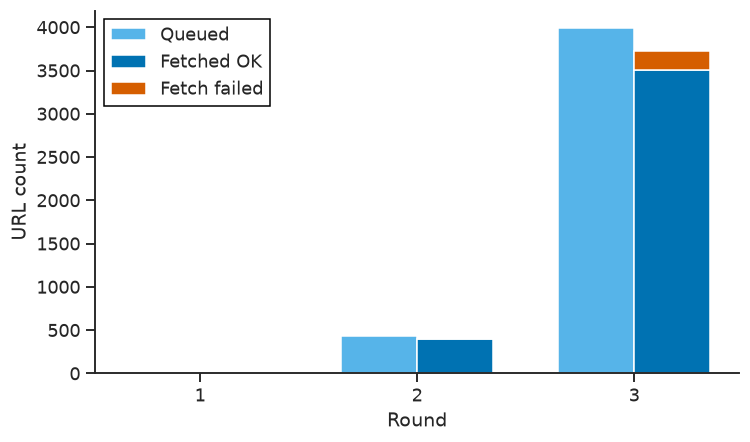

Caption: Queued vs. fetched (success/failed) URLs per round, session session_20260822_153136 (3 round(s), 4131 URLs fetched total, 230 failed).


In [4]:
fig, ax = plt.subplots()
width = 0.35
x = rounds["round"]
ax.bar(x - width/2, rounds["queued"], width, label="Queued", color=PALETTE[5])
ax.bar(x + width/2, rounds["fetch_success"], width, label="Fetched OK", color=PALETTE[0])
ax.bar(x + width/2, rounds["fetch_failed"], width, bottom=rounds["fetch_success"],
       label="Fetch failed", color=PALETTE[1])
ax.set_xlabel("Round")
ax.set_ylabel("URL count")
ax.set_xticks(x)
integer_axis(ax)
ax.legend()
fig.tight_layout()
savefig(fig, "session_round_sizes")
plt.show()
print(f"Caption: Queued vs. fetched (success/failed) URLs per round, session {SESSION} "
      f"({len(rounds)} round(s), {int(rounds['fetched'].sum())} URLs fetched total, "
      f"{int(rounds['fetch_failed'].sum())} failed).")

## Category composition per round

Stacked per-round view of which categories fetched pages landed in - the raw material for
"quality of links per round" (fewer `IRRELEVANT`/uncategorized pages relative to the
round's size means a higher-quality round).

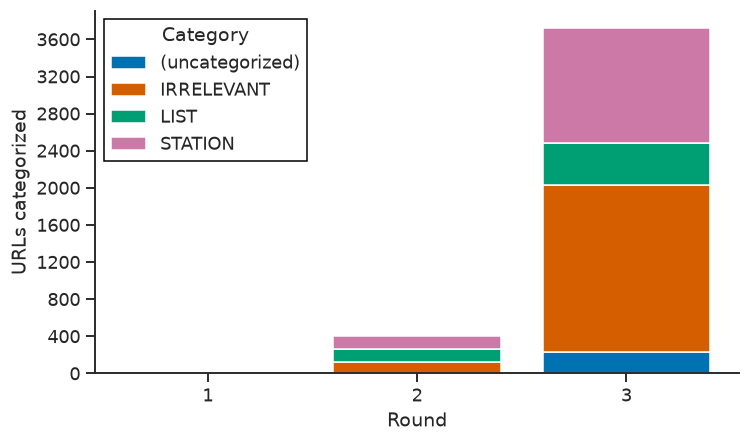

Caption: Category composition of fetched pages per round, session session_20260822_153136. '(uncategorized)' marks pages fetched but not yet categorized when monitoring stopped (e.g. an interrupted final round - see experiments/analyze_session.py's docstring on how an open-ended last round is handled).


In [5]:
fig, ax = plt.subplots()
bottom = pd.Series(0, index=rounds.index)
colors = [PALETTE[i % len(PALETTE)] for i in range(len(cat_columns))]
for col, color in zip(cat_columns, colors):
    label = col[len("cat_"):]
    ax.bar(rounds["round"], rounds[col], bottom=bottom, label=label, color=color)
    bottom = bottom + rounds[col]
ax.set_xlabel("Round")
ax.set_ylabel("URLs categorized")
ax.set_xticks(rounds["round"])
integer_axis(ax)
ax.legend(title="Category")
fig.tight_layout()
savefig(fig, "session_category_composition")
plt.show()
print(f"Caption: Category composition of fetched pages per round, session {SESSION}. "
      f"'(uncategorized)' marks pages fetched but not yet categorized when monitoring "
      f"stopped (e.g. an interrupted final round - see experiments/analyze_session.py's "
      f"docstring on how an open-ended last round is handled).")

### Category composition per round, as a percentage

Same data as the plot above, normalized to a 100%-stacked bar per round - makes the
*mix* comparable across rounds of very different absolute size (round 1 here is 6 URLs,
round 3 is thousands).

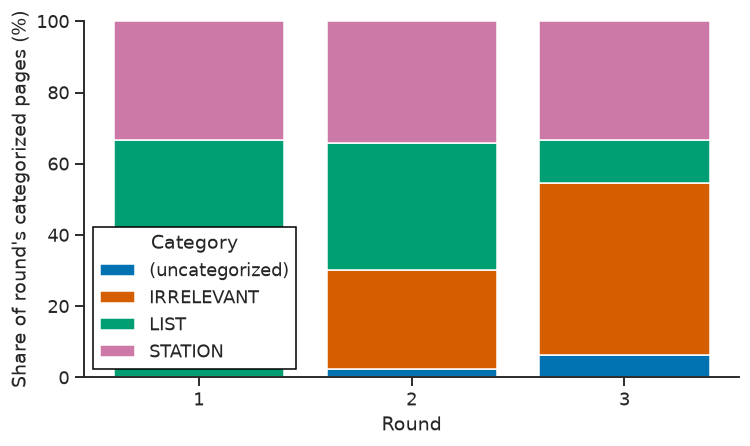

Caption: Category composition of fetched pages per round, as a percentage of that round's total, session session_20260822_153136. '(uncategorized)' marks pages fetched but not yet categorized when monitoring stopped.


In [6]:
round_totals = rounds[cat_columns].sum(axis=1).replace(0, pd.NA)

fig, ax = plt.subplots()
bottom = pd.Series(0.0, index=rounds.index)
for col, color in zip(cat_columns, colors):
    label = col[len("cat_"):]
    pct = 100 * rounds[col] / round_totals
    ax.bar(rounds["round"], pct, bottom=bottom, label=label, color=color)
    bottom = bottom + pct
ax.set_xlabel("Round")
ax.set_ylabel("Share of round's categorized pages (%)")
ax.set_ylim(0, 100)
ax.set_xticks(rounds["round"])
ax.legend(title="Category")
fig.tight_layout()
savefig(fig, "session_category_percentage_per_round")
plt.show()
print(f"Caption: Category composition of fetched pages per round, as a percentage of "
      f"that round's total, session {SESSION}. '(uncategorized)' marks pages fetched but "
      f"not yet categorized when monitoring stopped.")

## Link quality trend

The share of each round's fetched pages that landed in a *relevant* category, as a single
trend line - a rising line means discovery/link-following is increasingly reaching real,
useful content rather than unrelated pages.

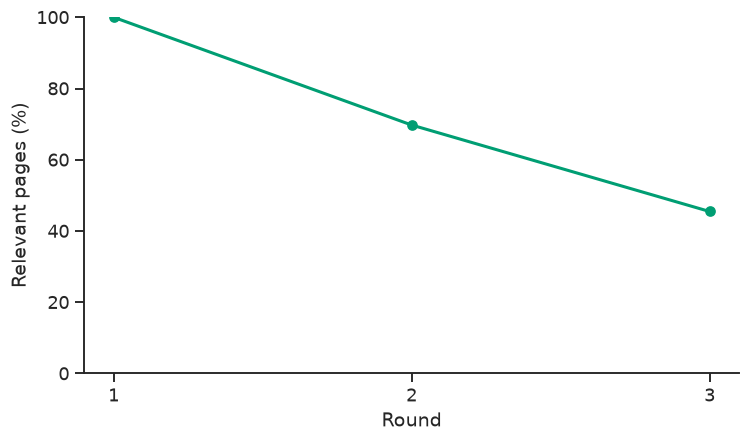

Caption: Share of each round's fetched pages classified as relevant (LIST, STATION) rather than irrelevant/uncategorized, session session_20260822_153136.


In [7]:
fig, ax = plt.subplots()
ax.plot(rounds["round"], rounds["relevant_ratio"] * 100, marker="o", color=PALETTE[2], linewidth=2)
ax.set_xlabel("Round")
ax.set_ylabel("Relevant pages (%)")
ax.set_xticks(rounds["round"])
ax.set_ylim(0, 100)
fig.tight_layout()
savefig(fig, "session_relevant_ratio")
plt.show()
relevant_names = ", ".join(c[len("cat_"):] for c in relevant_columns) or "none configured"
print(f"Caption: Share of each round's fetched pages classified as relevant "
      f"({relevant_names}) rather than irrelevant/uncategorized, session {SESSION}.")

## Usefulness of entries per round

The trend line above collapses each round to one "relevant %" number. This breaks that
back out by category, but keeps the useful/not-useful grouping visible: `STATION` and
`LIST` (both entry-producing, i.e. "useful") share a blue color family; `IRRELEVANT` and
`(uncategorized)` (both produce zero database entries - extraction is skipped for
`IRRELEVANT`, and `(uncategorized)` pages never reached extraction at all) share a
red/gray "not useful" family. Stacking `STATION`+`LIST` at the bottom of each bar makes
the useful/not-useful split readable at a glance while still showing the finer mix within
each half.

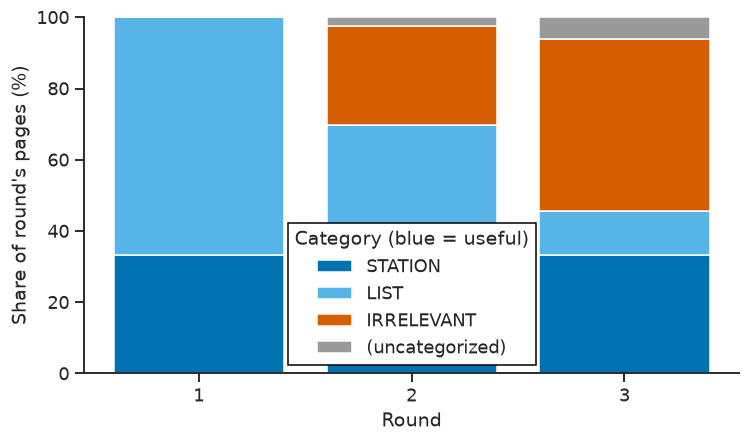

Caption: Usefulness of each round's pages, session session_20260822_153136 - STATION/LIST (entry-producing) vs. IRRELEVANT/(uncategorized) (zero entries), stacked to show both the useful/not-useful split and the finer category mix within each.
  round 1: 100.0% useful
  round 2: 69.8% useful
  round 3: 45.5% useful


In [8]:
# Useful (entry-producing) categories first so they stack at the bottom of the bar;
# color-coded by usefulness family (blue = useful, red/gray = not useful) rather than
# plotting.PALETTE's default per-category order.
USEFULNESS_ORDER = ["cat_STATION", "cat_LIST", "cat_IRRELEVANT", "cat_(uncategorized)"]
USEFULNESS_COLORS = {
    "cat_STATION": "#0072B2",        # blue - useful
    "cat_LIST": "#56B4E9",           # sky blue - useful
    "cat_IRRELEVANT": "#D55E00",     # vermillion - not useful
    "cat_(uncategorized)": "#999999",  # neutral gray - not useful (not yet known)
}
ordered_cols = [c for c in USEFULNESS_ORDER if c in cat_columns]

fig, ax = plt.subplots()
bottom = pd.Series(0.0, index=rounds.index)
for col in ordered_cols:
    label = col[len("cat_"):]
    pct = 100 * rounds[col] / round_totals
    ax.bar(rounds["round"], pct, bottom=bottom, label=label, color=USEFULNESS_COLORS[col])
    bottom = bottom + pct
ax.set_xlabel("Round")
ax.set_ylabel("Share of round's pages (%)")
ax.set_ylim(0, 100)
ax.set_xticks(rounds["round"])
ax.legend(title="Category (blue = useful)")
fig.tight_layout()
savefig(fig, "session_usefulness_per_round")
plt.show()

useful_pct = 100 * rounds[[c for c in ["cat_STATION", "cat_LIST"] if c in cat_columns]].sum(axis=1) / round_totals
print(f"Caption: Usefulness of each round's pages, session {SESSION} - STATION/LIST "
      f"(entry-producing) vs. IRRELEVANT/(uncategorized) (zero entries), stacked to show "
      f"both the useful/not-useful split and the finer category mix within each.")
for r, p in zip(rounds["round"], useful_pct):
    print(f"  round {int(r)}: {p:.1f}% useful")

## Round duration vs. link quality

A proxy for "time spent on useful vs. irrelevant websites": the production pipeline
doesn't split fetch/categorize/extract timing per page or per category (unlike
`experiments/collect_crawl_metrics.py`'s offline, per-URL measurement), so this can't
attribute wall-clock time to individual pages - but it can show whether irrelevant-heavy
rounds correlate with *rounds* that took longer overall, which is the closest read
available from round-level monitoring alone. Only rounds that ran to completion (have a
`round_end`) are included - an interrupted last round has no known duration.

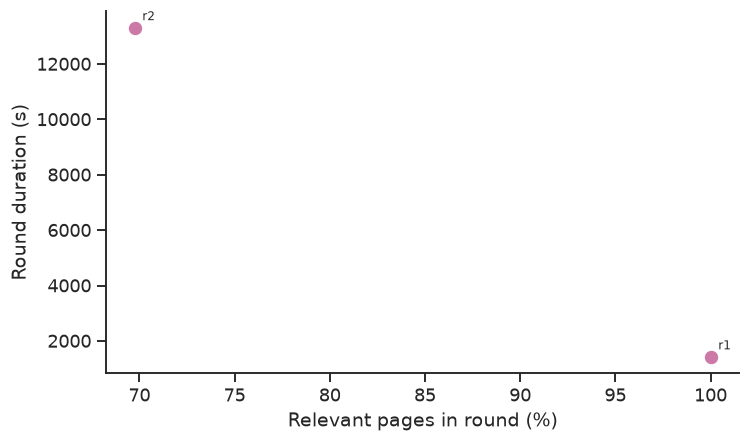

Caption: Round wall-clock duration vs. the share of that round's pages classified relevant, across 2 completed round(s) of session session_20260822_153136. Round-level granularity only, see the note above.


In [9]:
closed = rounds.dropna(subset=["round_seconds"])
if len(closed) >= 2:
    fig, ax = plt.subplots()
    ax.scatter(closed["relevant_ratio"] * 100, closed["round_seconds"], color=PALETTE[3], s=60)
    for _, r in closed.iterrows():
        ax.annotate(f"r{int(r['round'])}", (r["relevant_ratio"] * 100, r["round_seconds"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.set_xlabel("Relevant pages in round (%)")
    ax.set_ylabel("Round duration (s)")
    fig.tight_layout()
    savefig(fig, "session_duration_vs_quality")
    plt.show()
    print(f"Caption: Round wall-clock duration vs. the share of that round's pages "
          f"classified relevant, across {len(closed)} completed round(s) of session "
          f"{SESSION}. Round-level granularity only, see the note above.")
else:
    print(f"Only {len(closed)} completed round(s) with a known duration in session "
          f"{SESSION} - not enough for a duration-vs-quality plot (need >= 2).")

## Time spent: productive vs. unproductive pages, LIST vs. STATION extraction

The plot above is a round-level *proxy* for time spent on useful vs. irrelevant pages.
`model.orchestrator.process_batch()` now times each page's `categorize_website()` and
`extract_information()` calls individually (see `model.tools.monitor_service.page()`),
so this section measures it directly instead of inferring it from round duration.
"unproductive" here covers both `IRRELEVANT`-categorized pages and pages categorization
itself failed on (e.g. content too long for the model's context window - see
`category_service.categorize_website()`'s error handling); both cases still cost real
categorize-step time for zero extraction payoff.

In [10]:
page_timing = load_csv(f"{SESSION}_page_timing.csv")
if len(page_timing) > 0:
    page_timing["category"] = page_timing["category"].fillna("")
    page_timing["total_seconds"] = page_timing["categorize_seconds"] + page_timing["extract_seconds"]
    page_timing["is_relevant"] = page_timing["category"].map(lambda c: CATEGORY_RELEVANCE.get(c, False))
page_timing

,round,url,category,categorize_seconds,extract_seconds


### Time per round: productive vs. unproductive

Sums each round's per-page categorize+extract time, split by whether the page ended up
in a relevant category or not - the direct answer to "how much of this round's compute
went to pages that were actually worth it."

In [11]:
if len(page_timing) > 0:
    round_time = page_timing.groupby(["round", "is_relevant"])["total_seconds"].sum().unstack(fill_value=0)
    round_time = round_time.rename(columns={True: "Productive (relevant category)",
                                              False: "Unproductive (irrelevant/failed)"})
    for col in ["Productive (relevant category)", "Unproductive (irrelevant/failed)"]:
        if col not in round_time.columns:
            round_time[col] = 0.0

    fig, ax = plt.subplots()
    bottom = pd.Series(0.0, index=round_time.index)
    for label, color in zip(["Productive (relevant category)", "Unproductive (irrelevant/failed)"],
                             [PALETTE[0], PALETTE[1]]):
        ax.bar(round_time.index, round_time[label], bottom=bottom, label=label, color=color)
        bottom = bottom + round_time[label]
    ax.set_xlabel("Round")
    ax.set_ylabel("Categorize + extract time (s)")
    ax.set_xticks(round_time.index)
    ax.legend()
    fig.tight_layout()
    savefig(fig, "session_time_productive_vs_unproductive")
    plt.show()

    total_productive = page_timing.loc[page_timing["is_relevant"], "total_seconds"].sum()
    total_unproductive = page_timing.loc[~page_timing["is_relevant"], "total_seconds"].sum()
    total = total_productive + total_unproductive
    pct = 100 * total_productive / total if total else 0
    print(f"Caption: Categorize+extract wall-clock time per round, session {SESSION}, split by whether "
          f"the page was in a relevant category. {total_productive:.0f}s productive vs. "
          f"{total_unproductive:.0f}s unproductive overall ({pct:.0f}% of LLM time spent on relevant pages).")
else:
    print(f"No page timing data for session {SESSION} - it was captured before "
          f"model.orchestrator started emitting per-page timing events (or analyze_session.py "
          f"needs to be re-run against a session captured with the current code). Re-run the "
          f"crawl and analyze_session.py to populate this.")

No page timing data for session session_20260822_153136 - it was captured before model.orchestrator started emitting per-page timing events (or analyze_session.py needs to be re-run against a session captured with the current code). Re-run the crawl and analyze_session.py to populate this.


### LIST vs. STATION extraction time

LIST pages ask the model to extract every station entry on the page in one call; STATION
pages ask for a single entity. A longer LIST extraction time reflects that larger
single-call workload (more entries, more output tokens), not necessarily per-entry
inefficiency - worth keeping in mind when reading the comparison.

In [12]:
if len(page_timing) > 0 and set(page_timing["category"]) & {"LIST", "STATION"}:
    subset = page_timing[page_timing["category"].isin(["LIST", "STATION"])]
    labels = [c for c in ["LIST", "STATION"] if c in subset["category"].unique()]
    data_by_category = [subset.loc[subset["category"] == c, "extract_seconds"] for c in labels]

    fig, ax = plt.subplots()
    ax.boxplot(data_by_category, tick_labels=labels)
    for i, values in enumerate(data_by_category, start=1):
        ax.scatter([i] * len(values), values, color=PALETTE[3], alpha=0.6, zorder=3)
    ax.set_ylabel("Extraction time (s)")
    fig.tight_layout()
    savefig(fig, "session_extraction_time_list_vs_station")
    plt.show()

    summary = subset.groupby("category")["extract_seconds"].agg(["mean", "count"]).round(2)
    print(f"Caption: extract_information() wall-clock time for LIST vs. STATION pages, session {SESSION} "
          f"(points are individual pages, box shows the distribution).")
    summary
else:
    print(f"Not enough LIST/STATION page timing data in session {SESSION} to compare - nothing to plot.")

Not enough LIST/STATION page timing data in session session_20260822_153136 to compare - nothing to plot.


## Discovery yield per batch

How much each real search-discovery batch actually contributed during this session -
compare against `notebooks/discovery_yield.ipynb`'s isolated, repeatable measurement of
the same mechanism.

In [13]:
if len(discovery) > 0:
    fig, ax = plt.subplots()
    x = discovery["discovery_batch"]
    width = 0.4
    ax.bar(x - width/2, discovery["discovered_unique"], width, label="Unique URLs found", color=PALETTE[5])
    ax.bar(x + width/2, discovery["newly_queued"], width, label="...of which newly queued", color=PALETTE[1])
    ax.set_xlabel("Discovery batch")
    ax.set_ylabel("URL count")
    ax.set_xticks(x)
    integer_axis(ax)
    ax.legend()
    fig.tight_layout()
    savefig(fig, "session_discovery_yield")
    plt.show()
    print(f"Caption: Real search-discovery yield per batch during session {SESSION} - "
          f"unique URLs a batch returned vs. how many weren't already known/queued.")
else:
    print(f"Session {SESSION} never reached search-engine discovery (the fetch queue "
          f"never ran dry before monitoring stopped) - nothing to plot.")

Session session_20260822_153136 never reached search-engine discovery (the fetch queue never ran dry before monitoring stopped) - nothing to plot.


## Discussion

**What this is, and isn't.** Unlike the other notebooks' fixed, repeatable samples, this
data comes from one real, uncontrolled run - stopping conditions, interruptions, and which
URLs happened to be queued when are all incidental to that specific run, not a designed
experiment. Treat single-session numbers as a health check and a qualitative trend
("did quality improve as the run went on"), not as a statistically representative result -
re-running this notebook against multiple real sessions (different starting URLs, different
runtimes) before drawing a generalizable conclusion is recommended.

**Round-level granularity.** Fetch/category counts are re-derived from the `crawls` table
by binning `crawl_time` into each round's `[round_start, round_end)` window (see
`experiments/analyze_session.py`), not duplicated in the monitoring log itself - so this
notebook is only ever as fine-grained as "one round," never "one page." A handful of
crawls can fall outside every window (robots.txt-disallowed URLs, whose domain never got a
real request timestamp - see that script's `_bin_crawls_into_rounds()`) and are excluded
here; the script's own console output reports how many.

**Interrupted sessions.** A session with no `session_end` event (killed, crashed, still
running) still produces a full report - its last round is simply left open-ended and
includes every crawl at or after that round's start, rather than being dropped. That's the
reason `model.tools.monitor_service` writes its log continuously instead of only at the
end (see its docstring).

## CPU vs GPU: reconstructed real per-page timing

The CPU-baseline and GPU crawl sessions analyzed above both predate
`model.tools.monitor_service.page()` being wired into `process_batch()`, so neither
session log has real per-page `categorize_seconds`/`extract_seconds` events (see the
empty `_page_timing.csv` warnings above). What both machines' raw console logs (`INFO`/
`DEBUG` output, captured to `run_cpu_baseline.log` / `run_gpu.log`) *do* have is one log
line per page per phase - and since `process_batch()`'s categorize loop and extract loop
each process pages strictly one after another (never interleaved), the elapsed time
between two consecutive same-phase log lines reconstructs that page's real call
duration without needing the timing instrumentation to have been running.
`experiments/parse_run_log_timing.py` does this reconstruction; see its docstring for
the exact method.

**Two honest limitations of this reconstruction, not present in real `monitor_service`
timing:**
- Log timestamps are only precise to the second, so any call that completed in under a
  second is recorded as `0.0` - immaterial for the CPU run (calls take tens to hundreds
  of seconds) but relevant for the GPU run, where categorization is often genuinely
  sub-second.
- Both runs were captured mid-flight: whichever round was in progress when the log was
  captured has categorize data for (almost) every page but extraction data for only
  however many pages the (much slower, especially for `LIST`) extract loop had reached.
  Pages with no observed extraction outcome get `extract_seconds=""` (unknown), never a
  fabricated `0.0` - excluded from every plot below, not counted as fast extractions.
  This means the extract-time *share* of total time in the bar chart below is a floor,
  not the true share: both runs' true extract share is at least as large, likely larger.

In [14]:
cpu_page = load_csv("run_log_cpu_page_timing.csv")
gpu_page = load_csv("run_log_gpu_page_timing.csv")
cpu_fetch_phase = load_csv("run_log_cpu_fetch_phase.csv")
gpu_fetch_phase = load_csv("run_log_gpu_fetch_phase.csv")

for df in (cpu_page, gpu_page):
    df["extract_seconds"] = pd.to_numeric(df["extract_seconds"], errors="coerce")  # "" -> NaN (unknown)
    df["category"] = df["category"].fillna("")

print(f"CPU: {len(cpu_page)} page(s) ({cpu_page['extract_seconds'].notna().sum()} with known extract time), "
      f"{len(cpu_fetch_phase)} round(s)")
print(f"GPU: {len(gpu_page)} page(s) ({gpu_page['extract_seconds'].notna().sum()} with known extract time), "
      f"{len(gpu_fetch_phase)} round(s)")

CPU: 39 page(s) (6 with known extract time), 2 round(s)
GPU: 3899 page(s) (1038 with known extract time), 3 round(s)


### Time share per task: fetch vs. categorize vs. extract

Total observed wall-clock time in each phase, as a share of all observed time -
fetch-phase time is per-round (the whole batch fetches concurrently, so there's no
per-URL fetch duration), categorize/extract are summed over individual pages.

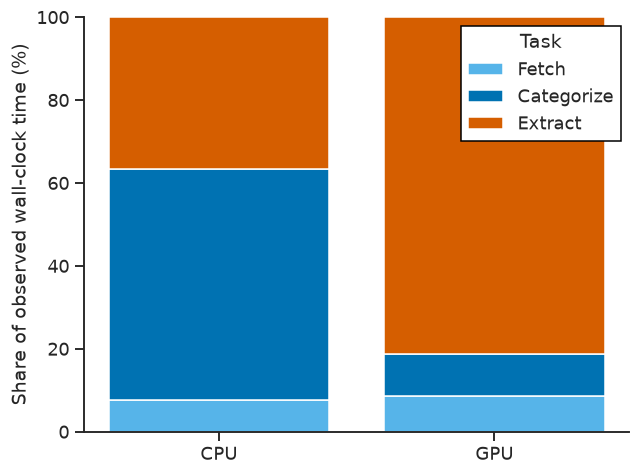

Caption: Share of observed real-session wall-clock time spent per task, CPU-baseline vs. GPU session (reconstructed from raw run logs - see limitations above; extract share is a floor, not the true share, for both sessions).
  CPU: Fetch=537s (7.6%), Categorize=3954s (55.9%), Extract=2581s (36.5%)
  GPU: Fetch=6322s (8.6%), Categorize=7470s (10.1%), Extract=59871s (81.3%)


In [15]:
def _task_shares(page_df, fetch_phase_df):
    fetch_s = fetch_phase_df["fetch_phase_seconds"].sum()
    cat_s = page_df["categorize_seconds"].sum()
    ext_s = page_df["extract_seconds"].sum(skipna=True)
    total = fetch_s + cat_s + ext_s
    return {"Fetch": fetch_s, "Categorize": cat_s, "Extract": ext_s}, total

cpu_shares, cpu_total = _task_shares(cpu_page, cpu_fetch_phase)
gpu_shares, gpu_total = _task_shares(gpu_page, gpu_fetch_phase)

tasks = ["Fetch", "Categorize", "Extract"]
fig, ax = plt.subplots(figsize=(6, 4.5))
bottom = {"CPU": 0.0, "GPU": 0.0}
colors = [PALETTE[5], PALETTE[0], PALETTE[1]]
for task, color in zip(tasks, colors):
    cpu_pct = 100 * cpu_shares[task] / cpu_total
    gpu_pct = 100 * gpu_shares[task] / gpu_total
    ax.bar("CPU", cpu_pct, bottom=bottom["CPU"], label=task, color=color)
    ax.bar("GPU", gpu_pct, bottom=bottom["GPU"], color=color)
    bottom["CPU"] += cpu_pct
    bottom["GPU"] += gpu_pct
ax.set_ylabel("Share of observed wall-clock time (%)")
ax.set_ylim(0, 100)
ax.legend(title="Task")
fig.tight_layout()
savefig(fig, "cpu_vs_gpu_task_time_share")
plt.show()

print(f"Caption: Share of observed real-session wall-clock time spent per task, CPU-baseline "
      f"vs. GPU session (reconstructed from raw run logs - see limitations above; extract "
      f"share is a floor, not the true share, for both sessions).")
for label, shares, total in [("CPU", cpu_shares, cpu_total), ("GPU", gpu_shares, gpu_total)]:
    print(f"  {label}: " + ", ".join(f"{t}={shares[t]:.0f}s ({100*shares[t]/total:.1f}%)" for t in tasks))

### Categorization time distribution: CPU vs. GPU

Every successfully-fetched page goes through categorization regardless of category, so
this includes all pages from both runs.

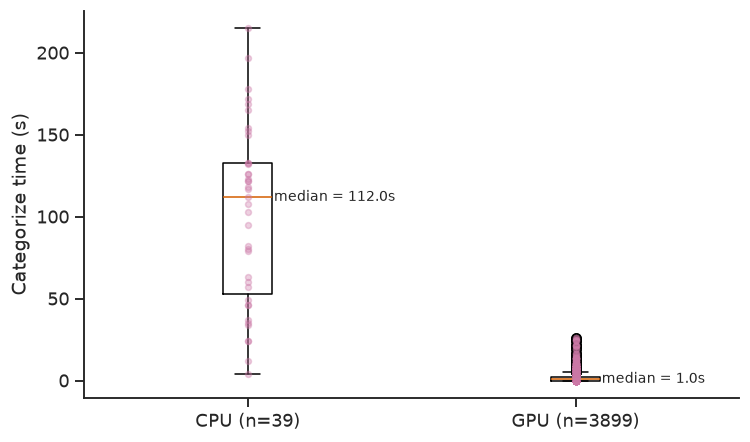

Caption: categorize_website() wall-clock time, CPU-baseline vs. GPU session (reconstructed from raw run logs; box shows median/IQR, whiskers 1.5x IQR, points are individual pages, median value labeled). Note the 1-second log-timestamp quantization - many GPU calls genuinely complete in under a second.


,CPU,GPU
count,39.000000,3899.000000
mean,101.384615,1.915876
std,54.607988,2.630504
min,4.000000,0.000000
25%,53.000000,0.000000
50%,112.000000,1.000000
75%,133.000000,2.000000
max,215.000000,26.000000


In [16]:
cat_data = [cpu_page["categorize_seconds"], gpu_page["categorize_seconds"]]
labels = [f"CPU (n={len(cpu_page)})", f"GPU (n={len(gpu_page)})"]

fig, ax = plt.subplots()
bp = ax.boxplot(cat_data, tick_labels=labels)
for i, values in enumerate(cat_data, start=1):
    ax.scatter([i] * len(values), values, color=PALETTE[3], alpha=0.35, s=15, zorder=3)
for i, median_line in enumerate(bp["medians"], start=1):
    median_val = median_line.get_ydata()[0]
    ax.annotate(f"median = {median_val:.1f}s", xy=(i + 0.08, median_val), va="center", fontsize=9)
ax.set_ylabel("Categorize time (s)")
fig.tight_layout()
savefig(fig, "cpu_vs_gpu_categorize_time")
plt.show()

summary = pd.DataFrame({
    "CPU": cpu_page["categorize_seconds"].describe(),
    "GPU": gpu_page["categorize_seconds"].describe(),
})
print("Caption: categorize_website() wall-clock time, CPU-baseline vs. GPU session "
      "(reconstructed from raw run logs; box shows median/IQR, whiskers 1.5x IQR, "
      "points are individual pages, median value labeled). Note the 1-second "
      "log-timestamp quantization - many GPU calls genuinely complete in under a second.")
summary

### Extraction time distribution: CPU vs. GPU

Restricted to `STATION`/`LIST` pages with a known extraction outcome - `IRRELEVANT`
pages return near-instantly (not a real "extraction" to compare), and pages with no
observed outcome (run stopped before reaching them) are excluded rather than treated as
zero (see the limitations note above).

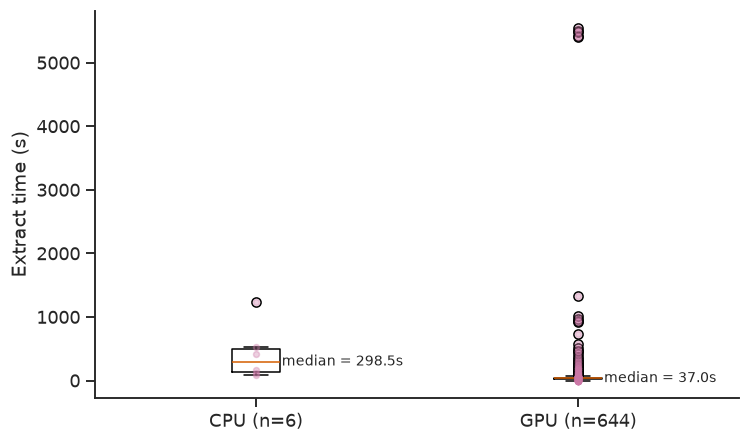

Caption: extract_information() wall-clock time for STATION/LIST pages with a known outcome, CPU-baseline vs. GPU session (reconstructed from raw run logs; box shows median/IQR, whiskers 1.5x IQR, points are individual pages, median value labeled). Small n for CPU - its session was interrupted early into its extraction phase.


,CPU,GPU
count,6.000000,644.000000
mean,430.166667,92.967391
std,432.816551,487.856610
min,96.000000,0.000000
25%,136.750000,25.000000
50%,298.500000,37.000000
75%,497.750000,47.000000
max,1241.000000,5544.000000


In [17]:
def _relevant_known_extract(df):
    return df[df["category"].isin(["STATION", "LIST"]) & df["extract_seconds"].notna()]["extract_seconds"]

cpu_ext = _relevant_known_extract(cpu_page)
gpu_ext = _relevant_known_extract(gpu_page)
ext_data = [cpu_ext, gpu_ext]
labels = [f"CPU (n={len(cpu_ext)})", f"GPU (n={len(gpu_ext)})"]

fig, ax = plt.subplots()
bp = ax.boxplot(ext_data, tick_labels=labels)
for i, values in enumerate(ext_data, start=1):
    ax.scatter([i] * len(values), values, color=PALETTE[3], alpha=0.35, s=15, zorder=3)
for i, median_line in enumerate(bp["medians"], start=1):
    median_val = median_line.get_ydata()[0]
    ax.annotate(f"median = {median_val:.1f}s", xy=(i + 0.08, median_val), va="center", fontsize=9)
ax.set_ylabel("Extract time (s)")
fig.tight_layout()
savefig(fig, "cpu_vs_gpu_extract_time")
plt.show()

summary = pd.DataFrame({"CPU": cpu_ext.describe(), "GPU": gpu_ext.describe()})
print("Caption: extract_information() wall-clock time for STATION/LIST pages with a "
      "known outcome, CPU-baseline vs. GPU session (reconstructed from raw run logs; "
      "box shows median/IQR, whiskers 1.5x IQR, points are individual pages, median "
      "value labeled). Small n for CPU - its session was interrupted early into its "
      "extraction phase.")
summary